# Lab 3: Programmatically Illustrate K-Nearest Neighbour Algorithm

## Objective
To implement the K-Nearest Neighbors (KNN) algorithm to classify a new data point based on similarity with labeled training data.

## Theory
The K-Nearest Neighbors (KNN) algorithm is a simple, non-parametric, and supervised machine learning technique used for classification and regression tasks. It works on the principle that similar data points exist close to each other in a feature space. In this implementation, KNN is used for classification, where a new (test) data point is assigned a class label based on the majority class among its k nearest neighbors from the training dataset.

Euclidean distance is commonly used to measure similarity between points. The formula for Euclidean distance is:

$$d = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

KNN is easy to implement and effective for small datasets, but its performance depends on the choice of k and the scale of features.

In [1]:
# Import Required Libraries
import numpy as np
from collections import Counter

In [2]:
# Define Euclidean Distance Function
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

In [3]:
# Define KNN Prediction Function
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

In [4]:
# Training Data and Labels
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']

# Test Data Point
test_point = [4, 7]
k = 3

# Predict Class
prediction = knn_predict(training_data, training_labels, test_point, k)
print("Test point:", test_point)
print("Predicted class:", prediction)

Test point: [4, 7]
Predicted class: B


## Discussion
In this lab, we implemented the K-Nearest Neighbors (KNN) algorithm using Python in VS Code. The algorithm was applied to classify a test data point based on its similarity to labeled training data. The Euclidean distance metric was used to calculate the distance between the test point and all training points. The top-k nearest neighbors were selected, and the majority class among these neighbors determined the predicted class. The implementation demonstrated the simplicity and effectiveness of KNN for small datasets.

## Conclusion
This lab provided hands-on experience with the KNN algorithm, showcasing its ability to classify data points based on proximity to labeled examples. While KNN is easy to implement and interpret, its performance depends on the choice of k and the scaling of features. The algorithm is computationally expensive for large datasets, but it remains a powerful tool for small-scale classification tasks.

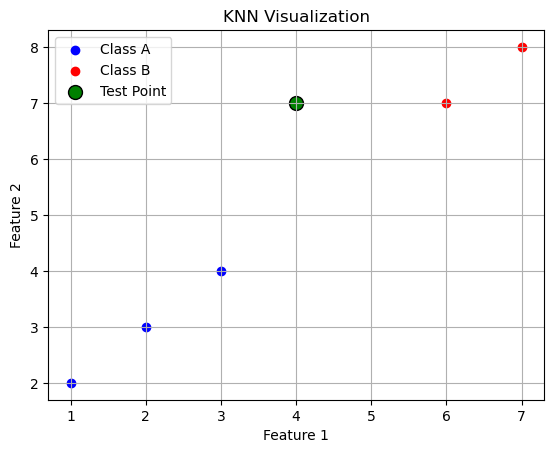

In [5]:
# Visualization of Training Data and Test Point
import matplotlib.pyplot as plt
import numpy as np

# Convert training data and labels to numpy arrays for easier handling
training_data_np = np.array(training_data)
training_labels_np = np.array(training_labels)

# Separate training data by class
class_A = training_data_np[training_labels_np == 'A']
class_B = training_data_np[training_labels_np == 'B']

# Plot training data
plt.scatter(class_A[:, 0], class_A[:, 1], color='blue', label='Class A')
plt.scatter(class_B[:, 0], class_B[:, 1], color='red', label='Class B')

# Plot test point
plt.scatter(test_point[0], test_point[1], color='green', label='Test Point', edgecolor='black', s=100)

# Add labels and legend
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KNN Visualization')
plt.legend()
plt.grid(True)
plt.show()